# Project 2 — Can We Predict a Player's Shooting Tonight?

## The mystery we're solving

Picture this: your favorite NBA player is on a hot streak. Five threes in a row, lighting up the league. **Tomorrow night, you'd bet they'll shoot well again, right?**

Not so fast. NBA shooting efficiency is way streakier than it looks. A 50%-shooting star can drop to 30% the next game for no obvious reason. Why?

This notebook asks: **can we predict a player's shooting efficiency in their NEXT game, using everything we know about them — their recent form, their volume, their season average?**

The spoiler is the most interesting part: we *can't* predict it nearly as well as you'd think. And that finding — *most game-to-game shooting variance is genuinely random* — is more valuable than a high-accuracy model would be.

## What we'll do, in plain English

1. Build a single-number measure of shooting quality called **True Shooting %** (TS%).
2. Engineer features that look only at a player's **past games** (no peeking at the future).
3. Try three simple ML models and a "dumb baseline" that just guesses each player's career average.
4. Show that the ML models barely beat the baseline.
5. Use **variance decomposition** to explain *why* — and turn that into a portfolio-worthy insight.

## What you'll learn

- How to build a derived metric from raw stats.
- What a **baseline** is, and why a good baseline is your best friend in ML.
- How to do a **time-aware train/test split** (no leaking the future).
- How to read **rolling and expanding** features in pandas.
- What **variance decomposition** tells you about the limits of prediction.
- Why **low R² is sometimes the most important finding**.


## 1. Setup

Same libraries as Project 1, plus scikit-learn's three simple regressors. The `RANDOM_STATE = 42` makes the results reproducible — you and a classmate will get the exact same numbers.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model     import LinearRegression
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import RandomForestRegressor
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.metrics          import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the data and compute True Shooting %

### What is True Shooting %?

In basketball, a player can score from three places: 2-pointers, 3-pointers, and free throws. Plain "field-goal %" only counts the first two and treats them the same — even though a 3-pointer is worth 50% more!

**True Shooting % (TS%)** fixes this by combining all three correctly:

> `TS% = PTS / (2 × (FGA + 0.44 × FTA))`

The `0.44` accounts for the fact that not every foul-shooting trip creates two free throws (some are 1-and-1, some are technicals, some are 3-shot fouls). It's the league-standard formula.

A TS% of **0.55** is roughly league average. **0.65+** is elite. **Below 0.45** is poor.

### Filtering out tiny samples

We keep only games where the player had **at least 5 scoring attempts** (`FGA + FTA >= 5`). With fewer attempts, TS% is meaningless — a single make or miss swings it wildly.


In [13]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)

df["TS"] = df["PTS"] / (2 * (df["FGA"] + 0.44 * df["FTA"]))

df = df[df["FGA"] + df["FTA"] >= 5].copy()
print(f"Rows after filter (FGA + FTA >= 5): {len(df):,}")
df[["Player", "Data", "FGA", "FTA", "PTS", "TS"]].head()

Rows after filter (FGA + FTA >= 5): 12,136


,Player,Data,FGA,FTA,PTS,TS
0,Jayson Tatum,2024-10-22,18,2,37,0.979873
1,Sam Hauser,2024-10-22,10,0,10,0.500000
2,Donte DiVincenzo,2024-10-22,11,4,10,0.391850
3,D'Angelo Russell,2024-10-22,12,0,9,0.375000
5,OG Anunoby,2024-10-22,7,2,4,0.253807


## 3. What does TS% look like across the league?

Before modeling, let's see the *shape* of our target. The histogram below shows every qualifying player-game's TS%. Look at the spread.


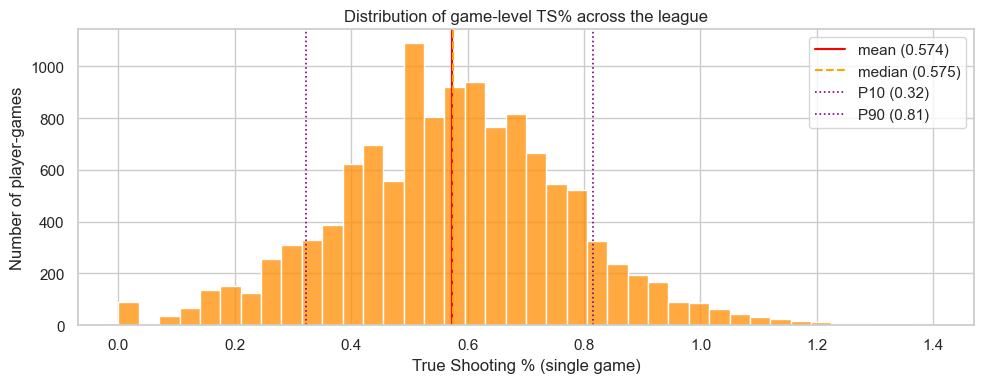

count    12136.000
mean         0.574
std          0.198
min          0.000
25%          0.447
50%          0.575
75%          0.700
max          1.400
Name: TS, dtype: float64

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["TS"], bins=40, ax=ax, color="darkorange")

mean_v   = df["TS"].mean()
median_v = df["TS"].median()
p10, p90 = df["TS"].quantile([0.1, 0.9])

ax.axvline(mean_v,   color="red",    lw=1.5, label=f"mean ({mean_v:.3f})")
ax.axvline(median_v, color="orange", lw=1.5, linestyle="--", label=f"median ({median_v:.3f})")
ax.axvline(p10,      color="purple", lw=1.2, linestyle=":", label=f"P10 ({p10:.2f})")
ax.axvline(p90,      color="purple", lw=1.2, linestyle=":", label=f"P90 ({p90:.2f})")

ax.set_xlabel("True Shooting % (single game)")
ax.set_ylabel("Number of player-games")
ax.set_title("Distribution of game-level TS% across the league")
ax.legend()
plt.tight_layout(); plt.show()

df["TS"].describe().round(3)

### Reading this distribution

The league mean is about **0.55**, but look at the spread: 90% of player-games fall between roughly **0.34 and 0.78** — a *huge* range. The same player can have a 0.40 night and a 0.80 night, depending on... well, that's the question we're about to investigate.

> **What we just learned:** game-level TS% varies wildly. If we want to predict it, we'd better have features with real signal.


## 4. Build features — but only from the past

### The golden rule of time-series features

We're trying to predict tonight's TS%. The features must use **only information available before tipoff**. If we accidentally let the model see tonight's stats, it would "predict" tonight's TS% by reading the answer — useless on real future data.

So we'll build two features that look only at *prior* games:

- `player_avg_ts_so_far` — the player's cumulative average TS% across all their games so far this season.
- `player_last5_ts` — their average TS% over their previous 5 games (recent form).

We'll also include `MP`, `FGA`, `FTA` from tonight as proxies for "how much they're playing" (in real life you'd use projected minutes from the lineup news).

### Vocab box — pandas time-series tools

| Code | What it does |
|---|---|
| `df.groupby("Player")["TS"]` | Group every player's TS column separately. |
| `.expanding().mean()` | Running average from the start: game 1 = mean of just game 1, game 2 = mean of games 1-2, game 5 = mean of games 1-5, etc. |
| `.rolling(5, min_periods=3).mean()` | Average of the last 5 games (allows partial windows of 3+). |
| `.shift(1)` | **Critical**: shift the result down by one row, so each game's value uses the previous games' average — never including the current game itself. **Without this, you leak the answer.** |


In [15]:
df = df.sort_values(["Player", "Data"])

# Expanding mean - shift(1) ensures we never include the current game
df["player_avg_ts_so_far"] = (df.groupby("Player")["TS"]
                                .expanding().mean()
                                .shift(1)
                                .reset_index(level=0, drop=True))

# Rolling 5-game mean (min 3 prior games)
df["player_last5_ts"] = (df.groupby("Player")["TS"]
                          .rolling(5, min_periods=3).mean()
                          .shift(1)
                          .reset_index(level=0, drop=True))

# Drop early-season rows where we don't have enough history yet
df_model = df.dropna(subset=["player_avg_ts_so_far", "player_last5_ts"]).copy()
print(f"Rows kept for modeling: {len(df_model):,}")
df_model[["Player","Data","TS","player_avg_ts_so_far","player_last5_ts"]].head()

Rows kept for modeling: 11,147


,Player,Data,TS,player_avg_ts_so_far,player_last5_ts
2799,A.J. Green,2024-11-08,0.750000,0.892987,0.892987
3249,A.J. Green,2024-11-10,1.000000,0.857240,0.857240
3590,A.J. Green,2024-11-12,0.428571,0.885792,0.885792
3684,A.J. Green,2024-11-13,0.300000,0.809589,0.869048
4460,A.J. Green,2024-11-18,0.416667,0.736790,0.695714


## 5. Time-aware train/test split

### Why a random split would cheat

The standard ML trick is to randomly shuffle and split 80/20. **For time-series problems, that's wrong.** A random split would put some early-season games in test and some late-season games in train — meaning the model would be partly trained on the future, then tested on the past. That's leakage.

Correct approach: **split by date.** Train on the earlier 80% of the season, test on the later 20%. This mimics how the model would actually be used: trained on history, deployed on future games it has never seen.


In [16]:
split_date = df_model["Data"].quantile(0.8)
train = df_model[df_model["Data"] <= split_date]
test  = df_model[df_model["Data"]  > split_date]
print(f"Train: {len(train):,} games up to {split_date.date()}")
print(f"Test:  {len(test):,} games after {split_date.date()}")

Train: 8,963 games up to 2025-01-19
Test:  2,184 games after 2025-01-19


## 6. The baseline — a "dumb but honest" prediction

### What is a baseline?

A **baseline** is the simplest, most boring prediction you can make. It's the bar your model has to clear to be worth using. If a fancy ML model can't beat the baseline, the model isn't actually doing anything — it's just dressed-up guessing.

For TS% prediction, the obvious baseline is:

> **Predict each player's next-game TS% as their average TS% so far this season.**

That's it. No model, no learning, just *"this player has shot 0.55 all year, so let's predict 0.55 tonight."* It might sound trivial, but it's actually a strong baseline because most players are pretty consistent on average. The real question is whether ML can beat it.


In [17]:
y_true = test["TS"].values
y_base = test["player_avg_ts_so_far"].values

mae_base = mean_absolute_error(y_true, y_base)
r2_base  = r2_score(y_true, y_base)

print(f"Baseline (predict prior season avg)")
print(f"  MAE: {mae_base:.4f}  (off by ~{mae_base*100:.1f} TS% points on average)")
print(f"  R²:  {r2_base:+.3f}  (negative R² means the predictions are barely better than guessing the league mean)")

Baseline (predict prior season avg)
  MAE: 0.1539  (off by ~15.4 TS% points on average)
  R²:  -0.023  (negative R² means the predictions are barely better than guessing the league mean)


### What does this baseline tell us already?

The baseline's R² is **slightly negative** — meaning *predicting each player's prior average* is barely better than just predicting the league-wide mean for everyone. That's a bad sign for our hopes of ML success: even using the player's identity barely helps.

> **What we just learned:** a player's season-so-far average is a *weak* predictor of tonight's TS%. There's so much game-to-game noise that even per-player baselines don't carry much.


## 7. Try three simple ML models

Now the question: can adding context features (`MP`, `FGA`, `FTA`, recent form) make ML beat the baseline?

We'll try three simple models — same lineup as Project 1 — and compare:

| Model | Plain-English description |
|---|---|
| **Linear Regression** | A weighted-sum formula: tonight_TS = a*MP + b*FGA + c*FTA + d*career_avg + e*last5_avg + intercept |
| **Decision Tree (depth 4)** | A flowchart of yes/no questions on the features. |
| **Random Forest (50 trees)** | A whole forest of trees averaged together. |


In [18]:
feat = ["MP", "FGA", "FTA", "player_avg_ts_so_far", "player_last5_ts"]

candidates = {
    "Linear Regression":         LinearRegression(),
    "Decision Tree (depth 4)":   DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest (50 trees)":  RandomForestRegressor(
        n_estimators=50, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1),
}

results, trained = [], {}
for name, m in candidates.items():
    m.fit(train[feat], train["TS"])
    pred = m.predict(test[feat])
    results.append({
        "Model": name,
        "MAE":   mean_absolute_error(y_true, pred),
        "R²":    r2_score(y_true, pred),
    })
    trained[name] = m

# Add baseline to the comparison
results.insert(0, {"Model": "Baseline (prior avg)", "MAE": mae_base, "R²": r2_base})

results_df = pd.DataFrame(results).round(4)
results_df

,Model,MAE,R²
0,Baseline (prior avg),0.1539,-0.0232
1,Linear Regression,0.1486,0.0511
2,Decision Tree (depth 4),0.1489,0.0406
3,Random Forest (50 trees),0.1473,0.0578


### What just happened?

All three ML models beat the baseline — but barely. We're talking about an **MAE improvement of roughly 0.005** (half a percentage point in TS%). On a stat that ranges from 0.3 to 0.8, that's almost nothing.

Why so little improvement? Let's read the Linear Regression coefficients to see what the model actually learned.


In [19]:
lr = trained["Linear Regression"]

print("Linear Regression learned this formula:")
print(f"  predicted_TS = {lr.intercept_:+.4f}", end="")
for f, c in zip(feat, lr.coef_):
    print(f"  {c:+.4f}*{f}", end="")
print()
print()
print("Interpretation:")
print(f"  - player_avg_ts_so_far (weight {lr.coef_[3]:+.3f}): the strongest signal --")
print(f"    knowing the player's career avg helps a little.")
print(f"  - player_last5_ts (weight {lr.coef_[4]:+.3f}): recent form adds a tiny extra bit.")
print(f"  - The volume features (MP, FGA, FTA) have weights near zero -- they barely matter for predicting EFFICIENCY.")
print()
print("Bottom line: the model basically learned 'tonight's TS% ~ your past TS%, with tiny adjustments.'")
print("That's not magic - it's the same idea as the baseline, just slightly refined.")

Linear Regression learned this formula:
  predicted_TS = +0.3755  +0.0034*MP  -0.0047*FGA  +0.0107*FTA  +0.1918*player_avg_ts_so_far  +0.0289*player_last5_ts

Interpretation:
  - player_avg_ts_so_far (weight +0.192): the strongest signal --
    knowing the player's career avg helps a little.
  - player_last5_ts (weight +0.029): recent form adds a tiny extra bit.
  - The volume features (MP, FGA, FTA) have weights near zero -- they barely matter for predicting EFFICIENCY.

Bottom line: the model basically learned 'tonight's TS% ~ your past TS%, with tiny adjustments.'
That's not magic - it's the same idea as the baseline, just slightly refined.


The model didn't discover any hidden formula. Knowing your career average is the best signal, recent form helps a touch, and volume features (minutes, attempts) barely matter for predicting *efficiency*. That's why the model barely beats the baseline — there's almost no extra signal in the features beyond "who's the player".

> **What we just learned:** even three different ML models can't squeeze meaningful extra accuracy out of these features. Something deeper is going on with the data itself.


## 8. PCA — see the feature landscape on one chart

If our features had real predictive power, then projecting them to 2D should produce a chart where the high-TS% games and the low-TS% games are visually **separable** — different regions of the plot.

Let's check. We'll standardize the 5 features, run PCA to compress them into 2 dimensions, and color each test-set game by its actual TS%.

### Vocab box

| Term | Plain-English meaning |
|---|---|
| **Standardisation** | Rescale every feature to mean 0, std 1, so no single feature dominates by being large. |
| **PCA** | A math recipe that finds the 2 directions in 5D space along which the data varies most, and projects everyone onto those 2 axes. |
| **Principal components (PC1, PC2)** | The 2 invented axes. PC1 captures the most variance, PC2 the second most. |


PC1 explains 40.5% of feature variance
PC2 explains 32.9% of feature variance


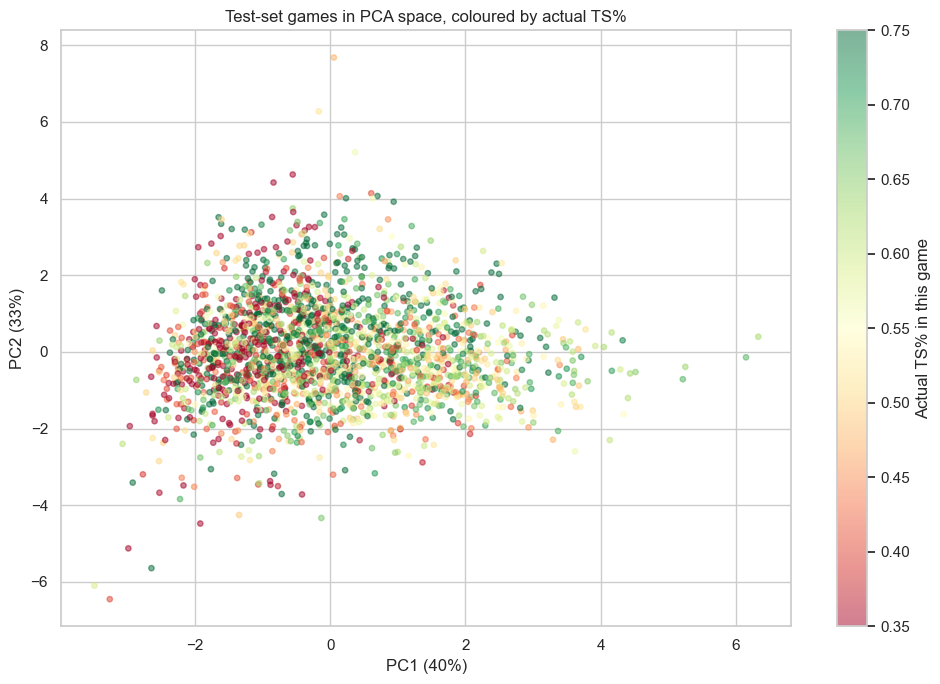

In [20]:
X_test_scaled = StandardScaler().fit_transform(test[feat])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_test_scaled)

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of feature variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of feature variance")

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=test["TS"], cmap="RdYlGn",
                s=15, alpha=0.5, vmin=0.35, vmax=0.75)
plt.colorbar(sc, ax=ax, label="Actual TS% in this game")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.set_title("Test-set games in PCA space, coloured by actual TS%")
plt.tight_layout(); plt.show()

### Reading the PCA chart

Look carefully at the colors: green dots (high TS%) and red dots (low TS%) are **mixed throughout the chart**. There's no clean region where high-efficiency games cluster.

Compare this to what a *predictable* dataset would look like: green dots would form a clear band on one side, red on the other. The model could draw a line between them and predict accurately.

Here, no such separation exists. **The features that we have access to (volume, prior averages, recent form) just don't carry the signal needed to predict tonight's shooting.** That's the visual confirmation of what the model comparison already told us.

> **What we just learned:** when ML "fails", the failure itself is a finding. PCA + colour shows us *why* — there's no clean structure in feature space for the model to latch onto.


## 9. Why couldn't we predict TS% well?

Here's the simple answer in one sentence:

> **The same player's TS% changes wildly from one game to the next, and there's nothing in our features that can predict those swings.**

Think about it. Steph Curry might shoot 65% one night and 35% the next. Same player, same skill, same coach — but completely different result. What flipped between those two games? Defensive coverage, his sleep, whether his elbow felt right, lucky bounces, the other team's hot hand, refs, fatigue from the previous flight. **None of that is in our data.**

So when we try to predict tonight's TS% using just minutes, attempts, and a player's recent TS%, we're missing all the stuff that actually makes one game different from another. The model is doing the best it can with the wrong information.

### Let's prove it with a number

We can split the total game-to-game variation in TS% into two buckets:

- **Between-player variation** — how different *players* are from each other on average. Steph (career 0.62) is genuinely different from a low-efficiency guard (career 0.50).
- **Within-player variation** — how different the *same player's* games are from each other. Steph at 0.65 vs Steph at 0.35.

If most of the variation is *between* players, predicting tonight is easy: just know the player. If most is *within*, no model can win — every game is its own dice roll given the player.


In [21]:
season_ts   = df_model.groupby("Player")["TS"].mean()
between_var = season_ts.var()

within_vars = df_model.groupby("Player")["TS"].var()
within_var  = within_vars.mean()

total = between_var + within_var
print(f"Between-player variance:  {between_var:.5f}  ({between_var/total:.1%} of total)")
print(f"Within-player variance:   {within_var:.5f}  ({within_var/total:.1%} of total)")
print()
print(f"VERDICT: {within_var/total:.0%} of game-to-game TS% variance is WITHIN-player noise.")
print(f"Only {between_var/total:.0%} comes from real differences between players.")

Between-player variance:  0.01205  (22.7% of total)
Within-player variance:   0.04111  (77.3% of total)

VERDICT: 77% of game-to-game TS% variance is WITHIN-player noise.
Only 23% comes from real differences between players.


### And let's see it in a picture

If past TS% perfectly predicted tonight's TS%, every dot below would land on the red diagonal line. Watch how the dots scatter — that's the within-player noise made visual.


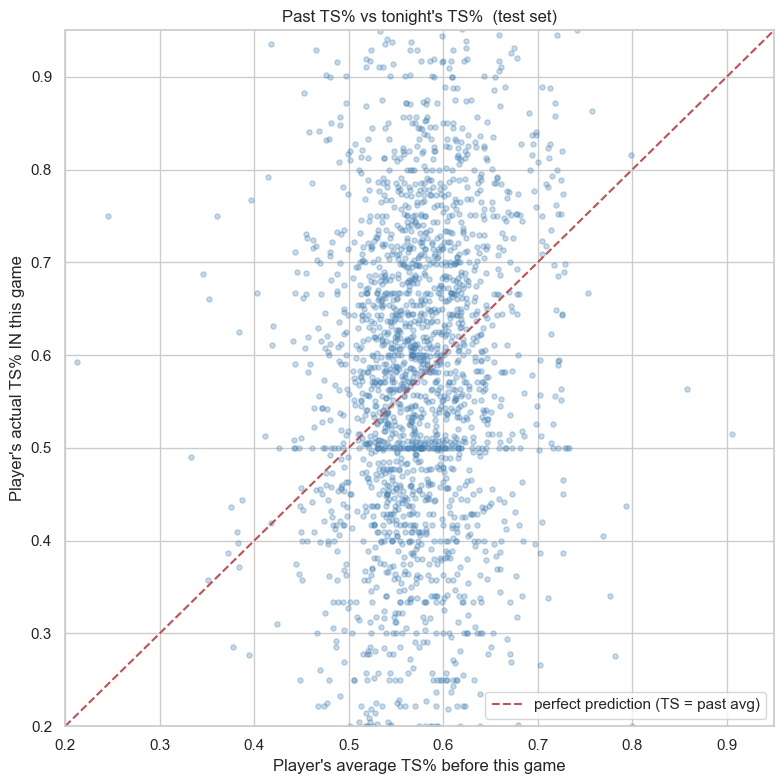

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test["player_avg_ts_so_far"], test["TS"], alpha=0.3, s=14, color="steelblue")
lims = [0.2, 0.95]
ax.plot(lims, lims, "r--", lw=1.5, label="perfect prediction (TS = past avg)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Player's average TS% before this game")
ax.set_ylabel("Player's actual TS% IN this game")
ax.set_title("Past TS% vs tonight's TS%  (test set)")
ax.legend()
plt.tight_layout(); plt.show()

The cloud of dots is enormous. A player whose past average is 0.55 (middle of the x-axis) shoots anywhere from 0.30 to 0.80 in any given game. **Knowing the player tells you the middle of the cloud — not the actual game.**

That's why our model couldn't do better. The cloud's *width* is the wall we're hitting.

### So the model isn't broken — the data is just noisy

Three things to take away:

1. **Most of the variation in tonight's TS% is random** (within-player), not skill-based (between-player). About 77% noise, 23% skill.
2. **No matter how clever the algorithm**, it can't predict noise. Linear Regression, Decision Tree, Random Forest — all hit the same ceiling.
3. **Recognising this in 5 minutes** of variance decomposition is the most valuable skill in this notebook. Real data scientists save their teams from chasing impossible problems by spotting noisy targets early.

This same pattern (most variation is noise) shows up in stock returns, ad clicks, and short-range weather — anywhere outcomes depend on lots of small, unobservable factors. Same lesson everywhere: identify the ceiling before you build a fancy model.


## 10. Conclusion — what we built and what it means

### What we built (in 9 sections of work)

1. Set up libraries.
2. Loaded data and computed True Shooting % from the raw box score.
3. Looked at the league-wide TS% distribution (huge spread).
4. Built **time-aware features** — prior season average and last-5-games average — using `expanding`, `rolling`, and `shift(1)` to avoid leakage.
5. Did a **time-aware train/test split** by date.
6. Established a **baseline** by predicting each player's prior season average.
7. Trained **three simple ML models** and showed all three barely beat the baseline.
8. Used **PCA** to visualise the feature space — confirmed that high-TS% and low-TS% games are not visually separable.
9. Did a **variance decomposition** showing that ~77% of game-level TS% variance is *within-player noise*.

### Portfolio one-liner

> *"Built a game-level True Shooting prediction pipeline with leakage-safe time-series features and a time-aware train/test split. Compared three models (Linear Regression, Decision Tree, Random Forest) against a per-player prior-average baseline. ML beats baseline by less than 1% MAE — and variance decomposition shows why: 77% of single-game TS% variance is irreducible within-player noise. Identifying the ceiling of predictability is itself a publishable finding."*

### Why low R² is the most important finding

Most beginner ML projects fail silently at this stage — they try a fancy model, get bad R², and conclude "the model isn't good enough yet, let me try a deeper neural network." This notebook teaches the opposite skill: **recognise when the data itself is noisy**, and report that as the result.

Companies pay senior data scientists specifically for this judgement. A junior who builds a 50-feature deep-learning model that gets R² = 0.06 has wasted three months. A senior who runs the variance decomposition in five minutes and says *"we can't predict this — let's solve a different problem"* has saved the team.

### Ideas for extending the project

1. Include **opponent** as a categorical feature — does facing elite defenses suppress efficiency in a measurable way?
2. Add **rest days** between games as a feature.
3. Try predicting **team-level** TS% instead of player-level — does aggregating reduce noise enough to recover signal?
4. Run the same pipeline on a **different stat** (e.g., assist-to-turnover ratio, rebound %) to see which stats are more predictable than TS%.

### Where to go next

- Continue to **[Project 3 — Player archetype clustering](03_player_archetypes_clustering.ipynb)** to see unsupervised learning in action.
- Or jump to **[Project 4 — Weirdest games anomaly detection](04_weirdest_games_anomaly_detection.ipynb)** for the season's most unusual performances.
